# Infra-FM: SatlasPretrain Sentinel-1 Linear Probe

Self-contained S1-only evaluation notebook.

- Loads SatlasPretrain `Sentinel1_SwinB_SI` (2-channel native, VH+VV).
- Reads `dataset_<region>_<sector>_v1_1k/` folders/zips from Drive.
- Selects S1 bands at indices `[8, 7]` (our `.npy` files store `[VV, VH]`;
  SatlasPretrain expects `[VH, VV]` — reverse the order at load time).
- Normalization: clip raw dB to `[-25, 0]` then rescale to `[0, 1]`.
  Bypasses the percentile_normalize used for the S2 path.
- 13-class taxonomy locked to match the S2 notebook for direct comparison.
- Linear probe only (frozen backbone). Saves a checkpoint every epoch to
  Drive in case the Colab session disconnects.
- Smoke-check is gated by `SMOKE_ONLY` (default True in cell 9). Flip to
  False and re-run the invocation cell to start the overnight training run.

Do not run this and `infra_fm_satlaspretrain_eval.ipynb` concurrently in
the same Colab runtime — they share `/content/datasets/` and would race
on extracts.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU. Runtime -> Change runtime type -> GPU before training.')


Mounted at /content/drive
GPU available: True
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
%%capture
!pip install satlaspretrain-models scikit-learn

In [3]:
import os
from pathlib import Path

# ---- Drive paths -----------------------------------------------------------
DRIVE_ROOT     = '/content/drive/MyDrive/infra_fm'
DATASETS_DRIVE = f'{DRIVE_ROOT}/datasets'
DATASETS_LOCAL = '/content/datasets'
OUTPUT_DIR     = f'{DRIVE_ROOT}/results/fm_eval_satlas_s1_v1'
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(DATASETS_LOCAL, exist_ok=True)

# ---- Coverage --------------------------------------------------------------
REGIONS = [
    'africa', 'asia', 'australia-oceania', 'central-america',
    'europe', 'north-america', 'south-america',
]
SECTORS = ['energy', 'water', 'transport', 'telecom']

# ---- 13-class taxonomy (locked, must match S2 notebook for fair comparison) ----
CLASS_NAMES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',          # pools substation_untyped + substation_minor
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.treatment.plant',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]
CLASS_TO_IDX        = {n: i for i, n in enumerate(CLASS_NAMES)}
CLASS_IDX_TO_SECTOR = {i: n.split('.')[0] for i, n in enumerate(CLASS_NAMES)}

ASSET_TYPE_MAP = {
    'energy.transmission.substation':         'energy.transmission.substation',
    'energy.distribution.substation':         'energy.distribution.substation',
    'energy.distribution.substation_untyped': 'energy.distribution.other',
    'energy.distribution.substation_minor':   'energy.distribution.other',
    'energy.generation.power_plant':          'energy.generation.power_plant',
    'energy.generation.solar_farm':           'energy.generation.solar_farm',
    'energy.generation.wind_farm':            'energy.generation.wind_farm',
    'water.wastewater.plant':                 'water.wastewater.plant',
    'water.treatment.plant':                  'water.treatment.plant',
    'water.storage_tank':                     'water.storage_tank',
    'transport.airport':                      'transport.airport',
    'transport.train_station':                'transport.train_station',
    'transport.port_terminal':                'transport.port_terminal',
    'telecom.data_center':                    'telecom.data_center',
}

# ---- S1-specific config ----------------------------------------------------
# Our .npy tiles are 9-band [B04, B03, B02, B08, B8A, B11, B12, VV, VH] in
# float32 dB scale (S1 bands were log-transformed by the STAC fetcher and
# clipped to [-30, 10] dB). SatlasPretrain S1 expects [VH, VV] band order,
# so we load with band_indices=[8, 7] to reverse our storage order.
S1_BAND_INDICES = [8, 7]   # VH first, then VV

# dB normalization: clip to [DB_MIN, DB_MAX] then linearly rescale to [0, 1].
# This bypasses the percentile_normalize used in the S2 notebook.
#
# SatlasPretrain S1 docs (README) say their preprocessing is
# "16-bit raw values divided by 255 and clipped to [0, 1]" — but our STAC
# fetch already log-transformed to dB, so we can't apply that exactly.
# Clipping dB to [-25, 0] then mapping to [0, 1] is a standard SAR
# normalization that lands inputs in the right range and reasonable
# dynamic range for SwinB-S1. **ASSUMPTION FLAG**: if S1 F1 comes in
# clearly weaker than S2 in the linear-probe comparison, the next
# experiment is to revisit normalization (revert dB -> linear amplitude
# then apply the exact 16-bit /255 recipe).
DB_MIN, DB_MAX = -25.0, 0.0

# ---- Training config -------------------------------------------------------
IMAGE_SIZE = 224              # SatlasPretrain-friendly; resized from native ~61x61
SEED       = 42
LP_EPOCHS  = 25               # mirrors the S2 linear-probe config
LP_BATCH   = 16
LP_LR      = 1e-3

# ---- Determinism -----------------------------------------------------------
def set_seed(seed: int) -> None:
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print(f'Regions ({len(REGIONS)}): {REGIONS}')
print(f'Sectors:                  {SECTORS}')
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'S1 band indices:          {S1_BAND_INDICES}  (VH, VV)')
print(f'S1 dB clip:               [{DB_MIN}, {DB_MAX}] -> [0, 1]')
print(f'Image size:               {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Linear probe:             {LP_EPOCHS} epochs, batch {LP_BATCH}, lr {LP_LR}')
print(f'Output dir:               {OUTPUT_DIR}')


Regions (7): ['africa', 'asia', 'australia-oceania', 'central-america', 'europe', 'north-america', 'south-america']
Sectors:                  ['energy', 'water', 'transport', 'telecom']
Classes (13): ['energy.transmission.substation', 'energy.distribution.substation', 'energy.distribution.other', 'energy.generation.power_plant', 'energy.generation.solar_farm', 'energy.generation.wind_farm', 'water.wastewater.plant', 'water.treatment.plant', 'water.storage_tank', 'transport.airport', 'transport.train_station', 'transport.port_terminal', 'telecom.data_center']
S1 band indices:          [8, 7]  (VH, VV)
S1 dB clip:               [-25.0, 0.0] -> [0, 1]
Image size:               224x224
Linear probe:             25 epochs, batch 16, lr 0.001
Output dir:               /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1


In [4]:
import zipfile, shutil, time, re
from pathlib import Path

drive_path = Path(DATASETS_DRIVE)
print(f'Contents of {DATASETS_DRIVE}:')
if drive_path.exists():
    for entry in sorted(drive_path.iterdir()):
        if entry.suffix == '.zip':
            size_gb = entry.stat().st_size / 1e9
            print(f'  {entry.name:<55s} {size_gb:>6.2f} GB')
        elif entry.is_dir():
            print(f'  {entry.name}/  (dir)')
else:
    raise RuntimeError(f'{DATASETS_DRIVE} not found — is Drive mounted?')
print()

MULTISECTOR_RE = re.compile(r'^dataset_([a-z-]+)_(energy|water|transport|telecom)_v1_1k$')

def discover_multisector_sources():
    sources, seen = [], set()
    for entry in sorted(drive_path.iterdir()):
        stem = entry.stem if entry.suffix == '.zip' else entry.name
        m = MULTISECTOR_RE.match(stem)
        if not m:
            continue
        region, sector = m.group(1), m.group(2)
        if region not in REGIONS:
            continue
        key = (region, sector)
        if key in seen:
            continue
        seen.add(key)
        sources.append((region, sector, entry, entry.suffix == '.zip'))
    return sources


def materialize_source(region, sector, src_path, is_zip, force=False):
    folder_name = f'dataset_{region}_{sector}_v1_1k'
    target_dir  = Path(DATASETS_LOCAL) / folder_name

    if not force and (target_dir / 'manifest.json').exists():
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'  [DONE]   {region:<22s} {sector:<10s} already present ({n} tiles)')
        return target_dir

    if not is_zip:
        if not (src_path / 'manifest.json').exists():
            print(f'  [EMPTY]  {region:<22s} {sector:<10s} no manifest.json in {src_path.name}')
            return None
        t0 = time.time()
        print(f'  [COPY]   {region:<22s} {sector:<10s} {src_path.name} -> {folder_name} ...',
              end=' ', flush=True)
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.copytree(src_path, target_dir)
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
        return target_dir

    # zip
    t0 = time.time()
    print(f'  [EXTRACT]{region:<22s} {sector:<10s} {src_path.name} -> {folder_name} ...',
          end=' ', flush=True)
    with zipfile.ZipFile(src_path) as zf:
        names = zf.namelist()
        wrapped_prefix = f'{folder_name}/'
        is_wrapped = any(n.startswith(wrapped_prefix) for n in names)
        if is_wrapped:
            zf.extractall(DATASETS_LOCAL)
        else:
            target_dir.mkdir(parents=True, exist_ok=True)
            zf.extractall(target_dir)
    n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
    print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
    return target_dir


discovered = discover_multisector_sources()
print(f'Found {len(discovered)} multi-sector v1 sources.\n')

ready = []
print('Materializing:')
for region, sector, src_path, is_zip in discovered:
    local = materialize_source(region, sector, src_path, is_zip)
    if local is None:
        continue
    if (local / 'manifest.json').exists() and any((local / 'images').glob('*.npy')):
        ready.append((region, sector, local))

print(f'\nReady: {len(ready)} (region, sector) pairs')


Contents of /content/drive/MyDrive/infra_fm/datasets:
  dataset_africa_energy_v1_1k.zip                           0.04 GB
  dataset_africa_stac_v1.zip                                0.18 GB
  dataset_africa_telecom_v1_1k.zip                          0.00 GB
  dataset_africa_transport_v1_1k.zip                        0.05 GB
  dataset_africa_water_v1_1k.zip                            0.04 GB
  dataset_asia_energy_v1_1k.zip                             0.04 GB
  dataset_asia_stac_v1.zip                                  0.76 GB
  dataset_asia_telecom_v1_1k.zip                            0.00 GB
  dataset_asia_transport_v1_1k.zip                          0.04 GB
  dataset_asia_water_v1_1k.zip                              0.05 GB
  dataset_australia-oceania_energy_v1_1k.zip                0.05 GB
  dataset_australia-oceania_stac_v1.zip                     0.11 GB
  dataset_australia-oceania_telecom_v1_1k (1).zip           0.00 GB
  dataset_australia-oceania_telecom_v1_1k.zip               0.

In [5]:
import json
import numpy as np
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from collections import Counter
import random


# ---------------------------------------------------------------------------
# Minimal S1-specific .npy dataset (self-contained — no curation/ dep).
# ---------------------------------------------------------------------------

@dataclass
class _Record:
    path: 'Path'
    asset_id: str
    asset_type: str


class NpyS1Dataset(Dataset):
    """Loads a single dataset_<region>_<sector>_v1_1k/ folder for S1.

    Differences vs. the canonical NpyInfrastructureDataset used in the
    S2 notebook:
      - selects S1 bands [8, 7] (VH, VV — reversed from .npy storage order)
      - normalization is dB clip [DB_MIN, DB_MAX] -> [0, 1], NOT
        percentile normalization (which would be a bad fit for SAR dB data)
    """
    def __init__(self, dataset_root, band_indices=S1_BAND_INDICES,
                 db_min=DB_MIN, db_max=DB_MAX,
                 allowed_asset_types=tuple(ASSET_TYPE_MAP.keys())):
        self.dataset_root  = Path(dataset_root)
        self.band_indices  = list(band_indices)
        self.db_min        = float(db_min)
        self.db_max        = float(db_max)
        self.allowed       = set(allowed_asset_types)

        manifest_path = self.dataset_root / 'manifest.json'
        if not manifest_path.exists():
            raise FileNotFoundError(f'missing manifest.json: {manifest_path}')
        with manifest_path.open() as f:
            manifest = json.load(f)
        records_in  = manifest.get('records', [])
        images_dir  = self.dataset_root / 'images'

        records, dropped = [], Counter()
        for r in records_in:
            at = r.get('asset_type')
            if not at:
                dropped['no_label'] += 1; continue
            if at not in self.allowed:
                dropped['filtered_type'] += 1; continue
            img_file = r.get('image_file')
            if not img_file:
                dropped['no_image_file'] += 1; continue
            p = images_dir / img_file
            if not p.exists():
                dropped['missing_npy'] += 1; continue
            # Quick band-count check so we fail fast if a tile is S2-only
            try:
                arr = np.load(p, mmap_mode='r')
                if arr.shape[0] < max(self.band_indices) + 1:
                    dropped['too_few_bands'] += 1; continue
            except Exception:
                dropped['load_error'] += 1; continue
            records.append(_Record(path=p, asset_id=r.get('asset_id', p.stem),
                                   asset_type=at))
        if dropped:
            reasons = ', '.join(f'{k}={v}' for k, v in dropped.items())
            print(f'  NpyS1Dataset({self.dataset_root.name}): dropped '
                  f'{sum(dropped.values())} records ({reasons})')
        if not records:
            raise RuntimeError(f'no usable S1 records in {self.dataset_root}')
        self.records = records

    def __len__(self):
        return len(self.records)

    def _load_image(self, path):
        arr = np.load(path)                     # (C, H, W) float32 dB
        arr = arr[self.band_indices, :, :]      # -> (2, H, W) [VH, VV]
        arr = np.clip(arr, self.db_min, self.db_max)
        arr = (arr - self.db_min) / (self.db_max - self.db_min)  # -> [0, 1]
        return arr.astype(np.float32)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = self._load_image(r.path)
        return {
            'image':      torch.from_numpy(img),
            'asset_id':   r.asset_id,
            'asset_type': r.asset_type,
        }


class MultiSectorLabelWrapper(Dataset):
    """Adds label mapping + resize + region/sector tagging on top of NpyS1Dataset."""
    def __init__(self, base, region, sector, input_size=IMAGE_SIZE):
        self.base = base
        self.region = region
        self.sector = sector
        self.input_size = input_size
        self.valid_indices, self.labels = [], []
        for i, r in enumerate(base.records):
            mapped = ASSET_TYPE_MAP.get(r.asset_type)
            if mapped is None:
                continue
            self.valid_indices.append(i)
            self.labels.append(CLASS_TO_IDX[mapped])

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        sample = self.base[self.valid_indices[idx]]
        img = sample['image']
        img = F.interpolate(img.unsqueeze(0), size=(self.input_size, self.input_size),
                            mode='bilinear', align_corners=False).squeeze(0)
        return {
            'image':    img,
            'label':    self.labels[idx],
            'asset_id': sample['asset_id'],
            'region':   self.region,
            'sector':   self.sector,
        }


class SubsetView(Dataset):
    def __init__(self, base, indices):
        self.base, self.indices = base, indices
        self.region, self.sector = base.region, base.sector
    def __len__(self): return len(self.indices)
    def __getitem__(self, i): return self.base[self.indices[i]]


def stratified_split(dataset, train_frac=0.7, val_frac=0.15, seed=SEED):
    by_class = {}
    for i, label in enumerate(dataset.labels):
        by_class.setdefault(label, []).append(i)
    rng = random.Random(seed)
    train, val, test = [], [], []
    for cls in sorted(by_class):
        idxs = by_class[cls].copy()
        rng.shuffle(idxs)
        n = len(idxs); n_tr = int(n * train_frac); n_va = int(n * val_frac)
        train.extend(idxs[:n_tr])
        val.extend(idxs[n_tr:n_tr + n_va])
        test.extend(idxs[n_tr + n_va:])
    return train, val, test


print('S1 dataset class + wrapper + split helpers ready.')


S1 dataset class + wrapper + split helpers ready.


In [6]:
source_datasets = {}
for region, sector, local in ready:
    try:
        base = NpyS1Dataset(local)
    except Exception as e:
        print(f'  {region:<22s} {sector:<10s} FAILED: {e}')
        continue
    ds = MultiSectorLabelWrapper(base, region=region, sector=sector)
    if len(ds) == 0:
        print(f'  {region:<22s} {sector:<10s} 0 valid samples (skipped)')
        continue
    source_datasets[(region, sector)] = ds

splits = {}
print(f'\n{"region":<22s} {"sector":<10s} {"train":>8s} {"val":>6s} {"test":>6s}')
print('-' * 60)
for key, ds in source_datasets.items():
    region, sector = key
    tr, va, te = stratified_split(ds)
    splits[key] = {
        'train': SubsetView(ds, tr),
        'val':   SubsetView(ds, va),
        'test':  SubsetView(ds, te),
    }
    print(f'{region:<22s} {sector:<10s} {len(tr):>8d} {len(va):>6d} {len(te):>6d}')

train_global = ConcatDataset([s['train'] for s in splits.values()])
val_global   = ConcatDataset([s['val']   for s in splits.values()])
test_global  = ConcatDataset([s['test']  for s in splits.values()])
print(f'\nGlobal: train={len(train_global)}  val={len(val_global)}  test={len(test_global)}')

# Combined class distribution.
print('\n=== Class distribution across all sources ===')
all_counts = Counter()
for ds in source_datasets.values():
    all_counts.update(ds.labels)
total = sum(all_counts.values())
for c, name in enumerate(CLASS_NAMES):
    n = all_counts.get(c, 0)
    pct = (100.0 * n / total) if total else 0.0
    print(f'  [{c:>2d}] {name:<34s} n={n:>6d}  ({pct:>5.2f}%)')
print(f'        {"TOTAL":<34s} n={total:>6d}')



region                 sector        train    val   test
------------------------------------------------------------
africa                 energy          661    141    147
africa                 telecom           0      0      1
africa                 transport       699    149    152
africa                 water           623    132    137
asia                   energy          619    131    139
asia                   telecom          19      4      5
asia                   transport       623    132    136
asia                   water           670    141    147
australia-oceania      energy          699    147    156
australia-oceania      telecom           8      1      3
australia-oceania      transport       698    149    153
australia-oceania      water           698    149    153
central-america        energy          696    147    156
central-america        telecom           0      0      1
central-america        transport       395     83     88
central-america        wat

In [7]:
import torch.nn as nn
import satlaspretrain_models as spm


class SatlasS1Backbone(nn.Module):
    """SatlasPretrain Sentinel-1 (VH+VV) SwinB backbone.

    Native 2-channel input; no first-conv adapter — passing 2 channels to a
    natively-2-channel pre-trained conv preserves the polarization-specific
    filters learned during pretraining. Band order [VH, VV] is enforced
    upstream by S1_BAND_INDICES=[8, 7] in the dataset loader.
    """
    NAME = 'satlas_pretrain_swinb_s1'
    FEATURE_DIM = 1024

    def __init__(self, freeze=False):
        super().__init__()
        weights_manager = spm.Weights()
        self.backbone = weights_manager.get_pretrained_model(
            model_identifier='Sentinel1_SwinB_SI',
            fpn=False,
        )
        self.feature_dim = self.FEATURE_DIM
        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        feature_maps = self.backbone(x)
        last = feature_maps[-1]                    # (B, C, H', W')
        return last.mean(dim=[2, 3])               # global avg pool -> (B, C)


class InfraBenchClassifier(nn.Module):
    def __init__(self, backbone, num_classes, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.feature_dim, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))


print('SatlasS1Backbone + InfraBenchClassifier defined.')


SatlasS1Backbone + InfraBenchClassifier defined.


In [8]:
from torch.optim import AdamW
from collections import defaultdict
from sklearn.metrics import f1_score, confusion_matrix
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


def _labels_from(dataset):
    if isinstance(dataset, ConcatDataset):
        for d in dataset.datasets:
            yield from _labels_from(d)
    elif isinstance(dataset, SubsetView):
        for i in dataset.indices:
            yield dataset.base.labels[i]
    else:
        yield from dataset.labels


def compute_class_weights(train_set, max_weight=10.0):
    """Inverse-frequency class weights, capped at max_weight; absent classes -> 0."""
    counts = Counter(_labels_from(train_set))
    total = sum(counts.values())
    weights = torch.zeros(len(CLASS_NAMES))
    for c in range(len(CLASS_NAMES)):
        if counts.get(c, 0) > 0:
            w = total / (len(CLASS_NAMES) * counts[c])
            weights[c] = min(w, max_weight)
    return weights


def collate(batch):
    return {
        'image':  torch.stack([b['image'] for b in batch]),
        'label':  torch.tensor([b['label'] for b in batch], dtype=torch.long),
        'region': [b['region'] for b in batch],
        'sector': [b['sector'] for b in batch],
    }


@torch.no_grad()
def evaluate(model, loader, return_breakdowns=False):
    model.eval()
    all_preds, all_labels, all_regions, all_sectors = [], [], [], []
    for batch in loader:
        logits = model(batch['image'].to(DEVICE, non_blocking=True))
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy().tolist())
        all_regions.extend(batch['region'])
        all_sectors.extend(batch['sector'])
    result = {
        'acc': float(np.mean(np.array(all_preds) == np.array(all_labels))),
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0.0)),
        'per_class_f1': f1_score(all_labels, all_preds, average=None,
                                 labels=list(range(len(CLASS_NAMES))),
                                 zero_division=0.0).tolist(),
        'confusion': confusion_matrix(all_labels, all_preds,
                                      labels=list(range(len(CLASS_NAMES)))).tolist(),
    }
    if return_breakdowns:
        def grouped_f1(group_vals):
            groups = defaultdict(lambda: {'preds': [], 'labels': []})
            for p, l, g in zip(all_preds, all_labels, group_vals):
                groups[g]['preds'].append(p)
                groups[g]['labels'].append(l)
            return {
                g: {
                    'n': len(d['labels']),
                    'macro_f1': float(f1_score(d['labels'], d['preds'], average='macro',
                                               zero_division=0.0)),
                    'acc': float(np.mean(np.array(d['preds']) == np.array(d['labels']))),
                }
                for g, d in groups.items()
            }
        result['per_region'] = grouped_f1(all_regions)
        result['per_sector'] = grouped_f1(all_sectors)
    return result


def train_one_run(backbone_factory, train_set, val_set, test_set, *,
                  freeze_backbone, num_epochs, batch_size, lr,
                  weight_decay=1e-4, num_workers=2, run_name='run'):
    backbone = backbone_factory(freeze=freeze_backbone)
    model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)

    weights = compute_class_weights(train_set).to(DEVICE)
    print('  Class weights:')
    for c, w in enumerate(weights.cpu().numpy()):
        print(f'    [{c:>2d}] {CLASS_NAMES[c]:<34s} {w:.4f}')
    criterion = nn.CrossEntropyLoss(weight=weights)

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=lr, weight_decay=weight_decay)

    ckpt_dir = Path(OUTPUT_DIR) / run_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    history, best_val_f1 = [], -1.0
    for epoch in range(num_epochs):
        model.train()
        t0 = time.time()
        loss_sum, n = 0.0, 0
        for batch in train_loader:
            images = batch['image'].to(DEVICE, non_blocking=True)
            labels = batch['label'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * images.size(0)
            n += images.size(0)
        train_loss = loss_sum / max(n, 1)
        val = evaluate(model, val_loader)
        history.append({
            'epoch': epoch + 1, 'train_loss': train_loss,
            'val_acc': val['acc'], 'val_macro_f1': val['macro_f1'],
            'time_s': time.time() - t0,
        })
        # Save latest checkpoint every epoch in case Colab session dies.
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'best_val_f1': best_val_f1,
        }, ckpt_dir / 'checkpoint_latest.pt')

        marker = ''
        if val['macro_f1'] > best_val_f1:
            best_val_f1 = val['macro_f1']
            marker = ' *'
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_macro_f1': val['macro_f1'],
                'history': history,
            }, ckpt_dir / 'checkpoint_best.pt')
        print(f'  ep {epoch+1:>3d}  loss={train_loss:.4f}  '
              f'val_acc={val["acc"]:.4f}  val_f1={val["macro_f1"]:.4f}{marker}')

    tail = [h['val_macro_f1'] for h in history[-min(5, len(history)):]]
    test = evaluate(model, test_loader, return_breakdowns=True)
    return {
        'run_name': run_name,
        'backbone': backbone.NAME,
        'condition': 'linear_probe' if freeze_backbone else 'fine_tune',
        'num_epochs': num_epochs,
        'best_val_f1': best_val_f1,
        'tail_mean_f1': float(np.mean(tail)),
        'tail_std_f1': float(np.std(tail)),
        'history': history,
        'test': test,
    }


print('Training infrastructure ready.')


Device: cuda
Training infrastructure ready.


In [9]:
# ============================================================================
# SMOKE CHECK — load backbone, build one batch, run forward pass. No training.
# ============================================================================
# Flip SMOKE_ONLY to False (in the invocation cell below) once you're satisfied
# this passes. With SMOKE_ONLY=True the invocation cell exits before training.

SMOKE_ONLY = False

def build_satlas_s1_backbone(freeze):
    return SatlasS1Backbone(freeze=freeze)

print('Loading SatlasPretrain S1 backbone (frozen)...')
backbone = build_satlas_s1_backbone(freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)
model.eval()

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total params:     {n_total:>12,}')
print(f'  Trainable params: {n_trainable:>12,}  (linear probe: should be << total)')

print('\nPulling one batch from train_global...')
smoke_loader = DataLoader(train_global, batch_size=4, shuffle=False,
                          num_workers=0, collate_fn=collate)
batch = next(iter(smoke_loader))
img = batch['image']
print(f'  Batch image shape:  {tuple(img.shape)}  (expect [4, 2, {IMAGE_SIZE}, {IMAGE_SIZE}])')
print(f'  Batch image dtype:  {img.dtype}')
print(f'  Batch image range:  [{img.min().item():.4f}, {img.max().item():.4f}]  (expect ~[0, 1])')
print(f'  Batch image mean:   {img.mean().item():.4f}')
print(f'  Batch labels:       {batch["label"].tolist()}')
print(f'  Batch regions:      {batch["region"]}')
print(f'  Batch sectors:      {batch["sector"]}')

print('\nForward pass...')
with torch.no_grad():
    logits = model(img.to(DEVICE))
print(f'  Logits shape:       {tuple(logits.shape)}  (expect [4, {len(CLASS_NAMES)}])')
print(f'  Logits range:       [{logits.min().item():.4f}, {logits.max().item():.4f}]')
print(f'  Predicted classes:  {logits.argmax(dim=1).cpu().tolist()}')
print('\nSmoke check PASSED. S1 backbone loads and forward pass works.')
print(f'\nSMOKE_ONLY = {SMOKE_ONLY}  — the invocation cell below will '
      f'{"NOT train" if SMOKE_ONLY else "TRAIN"}.')


Loading SatlasPretrain S1 backbone (frozen)...
  Total params:       87,942,125
  Trainable params:       13,325  (linear probe: should be << total)

Pulling one batch from train_global...
  Batch image shape:  (4, 2, 224, 224)  (expect [4, 2, 224, 224])
  Batch image dtype:  torch.float32
  Batch image range:  [0.0000, 1.0000]  (expect ~[0, 1])
  Batch image mean:   0.4002
  Batch labels:       [0, 0, 0, 0]
  Batch regions:      ['africa', 'africa', 'africa', 'africa']
  Batch sectors:      ['energy', 'energy', 'energy', 'energy']

Forward pass...
  Logits shape:       (4, 13)  (expect [4, 13])
  Logits range:       [-1.9507, 1.9304]
  Predicted classes:  [7, 7, 7, 7]

Smoke check PASSED. S1 backbone loads and forward pass works.

SMOKE_ONLY = False  — the invocation cell below will TRAIN.


In [12]:
# ============================================================================
# LINEAR PROBE INVOCATION — gated by SMOKE_ONLY from the cell above.
# ============================================================================
import json as _json

if SMOKE_ONLY:
    print('SMOKE_ONLY=True — skipping training. '
          'Set SMOKE_ONLY=False in the smoke-check cell, re-run that cell '
          'and then this one to start the overnight run.')
else:
    print('=' * 70)
    print('SatlasPretrain S1 — Linear Probe (frozen backbone)')
    print(f'  REGIONS = {len(REGIONS)}, classes = {len(CLASS_NAMES)}, '
          f'epochs = {LP_EPOCHS}, batch = {LP_BATCH}, lr = {LP_LR}')
    print('=' * 70)

    results = {}
    results['linear_probe'] = train_one_run(
        backbone_factory=build_satlas_s1_backbone,
        train_set=train_global, val_set=val_global, test_set=test_global,
        freeze_backbone=True,
        num_epochs=LP_EPOCHS,
        batch_size=LP_BATCH,
        lr=LP_LR,
        run_name='satlas_s1_v1_linear_probe',
    )

    out_path = Path(OUTPUT_DIR) / 'satlas_s1_v1_linear_probe_results.json'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, 'w') as f:
        _json.dump(results, f, indent=2)
    print(f'\nResults saved to: {out_path}')

    lp = results['linear_probe']
    print(f'\n=== S1 Linear Probe Summary ===')
    print(f'Best val F1:     {lp["best_val_f1"]:.4f}')
    print(f'Tail mean F1:    {lp["tail_mean_f1"]:.4f} +/- {lp["tail_std_f1"]:.4f}')
    print(f'Test macro F1:   {lp["test"]["macro_f1"]:.4f}')
    print(f'Test accuracy:   {lp["test"]["acc"]:.4f}')

    print(f'\nPer-class F1 (test):')
    for c, name in enumerate(CLASS_NAMES):
        print(f'  [{c:>2d}] {name:<34s} {lp["test"]["per_class_f1"][c]:.4f}')

    print(f'\nPer-sector F1 (test):')
    for sector, stats in sorted(lp['test']['per_sector'].items()):
        print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')

    print(f'\nPer-region F1 (test):')
    for region, stats in sorted(lp['test']['per_region'].items()):
        print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')


SatlasPretrain S1 — Linear Probe (frozen backbone)
  REGIONS = 7, classes = 13, epochs = 25, batch = 16, lr = 0.001
  Class weights:
    [ 0] energy.transmission.substation     2.1460
    [ 1] energy.distribution.substation     1.4823
    [ 2] energy.distribution.other          0.4412
    [ 3] energy.generation.power_plant      2.6626
    [ 4] energy.generation.solar_farm       2.2979
    [ 5] energy.generation.wind_farm        10.0000
    [ 6] water.wastewater.plant             1.1097
    [ 7] water.treatment.plant              1.6155
    [ 8] water.storage_tank                 0.3604
    [ 9] transport.airport                  1.6554
    [10] transport.train_station            0.2852
    [11] transport.port_terminal            10.0000
    [12] telecom.data_center                2.7349
  ep   1  loss=2.3930  val_acc=0.1915  val_f1=0.1537 *
  ep   2  loss=2.3443  val_acc=0.1915  val_f1=0.1488
  ep   3  loss=2.3234  val_acc=0.1955  val_f1=0.1430
  ep   4  loss=2.2955  val_acc=0.2488  va

## analyzing best checkpoint

In [10]:
# Sanity check that everything's loaded
print(f'train_global: {len(train_global) if "train_global" in dir() else "MISSING"}')
print(f'test_global: {len(test_global) if "test_global" in dir() else "MISSING"}')
print(f'evaluate: {"defined" if "evaluate" in dir() else "MISSING"}')
print(f'collate: {"defined" if "collate" in dir() else "MISSING"}')
print(f'SatlasS1Backbone: {"defined" if "SatlasS1Backbone" in dir() else "MISSING"}')
print(f'DEVICE: {DEVICE if "DEVICE" in dir() else "MISSING"}')

train_global: 13084
test_global: 2899
evaluate: defined
collate: defined
SatlasS1Backbone: defined
DEVICE: cuda


In [9]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

# Load best-val checkpoint from the S1 run
ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/satlas_s1_v1_linear_probe/checkpoint_best.pt')

# Verify it exists
if not ckpt_path.exists():
    # Try the older path from the disconnected run
    ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_multisector_v1/satlas_s1_full7region_v1_linear_probe_capped/checkpoint_best.pt')
print(f'Using checkpoint: {ckpt_path}')
print(f'Exists: {ckpt_path.exists()}')

# Build model
backbone = SatlasS1Backbone(freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\nLoaded checkpoint:')
print(f'  Epoch: {ckpt["epoch"]}')
print(f'  Val macro F1: {ckpt["val_macro_f1"]:.4f}')

# Build test loader using the S1-wrapped test set
# IMPORTANT: this assumes test_global in the current runtime is already S1-wrapped
# (i.e., it was set up by the S1 notebook's data loading cell, not the S2 one)
test_loader = DataLoader(
    test_global, batch_size=16, shuffle=False,
    num_workers=2, collate_fn=collate, pin_memory=True
)

# Run evaluation
test_result = evaluate(model, test_loader, return_breakdowns=True)

# Print results
print(f'\n=== S1 Best-Checkpoint Test Results ===')
print(f'Test macro F1: {test_result["macro_f1"]:.4f}')
print(f'Test accuracy: {test_result["acc"]:.4f}')

print(f'\nPer-class F1:')
for c, name in enumerate(CLASS_NAMES):
    print(f'  [{c:>2d}] {name:<34s} {test_result["per_class_f1"][c]:.4f}')

print(f'\nPer-sector F1:')
for sector, stats in sorted(test_result['per_sector'].items()):
    print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}')

print(f'\nPer-region F1:')
for region, stats in sorted(test_result['per_region'].items()):
    print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}')

Using checkpoint: /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/satlas_s1_v1_linear_probe/checkpoint_best.pt
Exists: True

Loaded checkpoint:
  Epoch: 23
  Val macro F1: 0.2169

=== S1 Best-Checkpoint Test Results ===
Test macro F1: 0.1910
Test accuracy: 0.2553

Per-class F1:
  [ 0] energy.transmission.substation     0.1558
  [ 1] energy.distribution.substation     0.1000
  [ 2] energy.distribution.other          0.2583
  [ 3] energy.generation.power_plant      0.2119
  [ 4] energy.generation.solar_farm       0.1481
  [ 5] energy.generation.wind_farm        0.0000
  [ 6] water.wastewater.plant             0.1483
  [ 7] water.treatment.plant              0.0387
  [ 8] water.storage_tank                 0.1550
  [ 9] transport.airport                  0.5057
  [10] transport.train_station            0.3727
  [11] transport.port_terminal            0.0000
  [12] telecom.data_center                0.3882

Per-sector F1:
  energy     n=  953  F1=0.1174
  telecom    n=   87  F

In [10]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader
import pickle

# Build model
backbone = SatlasS1Backbone(freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

# Load best checkpoint
ckpt_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/satlas_s1_v1_linear_probe/checkpoint_best.pt')
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded checkpoint: epoch {ckpt["epoch"]}, val_f1={ckpt["val_macro_f1"]:.4f}')

# Build test loader (assumes test_global is S1-wrapped from the S1 notebook's data cells)
test_loader = DataLoader(
    test_global, batch_size=16, shuffle=False,
    num_workers=2, collate_fn=collate, pin_memory=True
)

# Run eval
test_result_s1 = evaluate(model, test_loader, return_breakdowns=True)
print(f'\nS1 best-checkpoint test F1: {test_result_s1["macro_f1"]:.4f}')
print(f'S1 best-checkpoint test accuracy: {test_result_s1["acc"]:.4f}')

# IMPORTANT: save to disk so we don't lose it again
import json
out_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/satlas_s1_v1_best_checkpoint_test_result.json')
# Convert numpy arrays to lists for JSON serialization
test_result_serializable = {
    'macro_f1': float(test_result_s1['macro_f1']),
    'acc': float(test_result_s1['acc']),
    'per_class_f1': [float(x) for x in test_result_s1['per_class_f1']],
    'confusion': test_result_s1['confusion'].tolist() if hasattr(test_result_s1['confusion'], 'tolist') else test_result_s1['confusion'],
    'per_sector': {k: {kk: (float(vv) if isinstance(vv, (int, float)) else vv) for kk, vv in v.items()} for k, v in test_result_s1['per_sector'].items()},
    'per_region': {k: {kk: (float(vv) if isinstance(vv, (int, float)) else vv) for kk, vv in v.items()} for k, v in test_result_s1['per_region'].items()},
    'source_epoch': int(ckpt['epoch']),
    'source_val_f1': float(ckpt['val_macro_f1']),
}
with open(out_path, 'w') as f:
    json.dump(test_result_serializable, f, indent=2)
print(f'\nSaved to: {out_path}')

Loaded checkpoint: epoch 23, val_f1=0.2169

S1 best-checkpoint test F1: 0.1910
S1 best-checkpoint test accuracy: 0.2553

Saved to: /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/satlas_s1_v1_best_checkpoint_test_result.json


Saved to: /content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/confusion_matrix_s1_7region.png


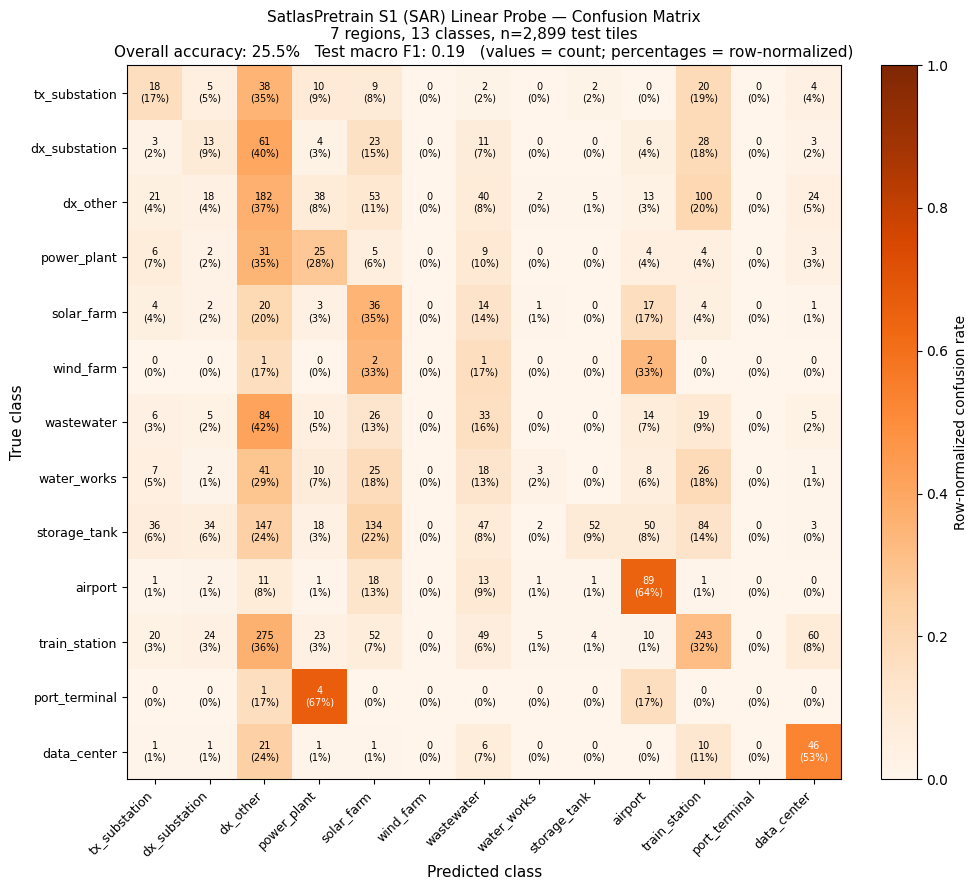

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cm_s1 = np.array(test_result_s1['confusion'])

CLASS_NAMES_SHORT = [
    'tx_substation',
    'dx_substation',
    'dx_other',
    'power_plant',
    'solar_farm',
    'wind_farm',
    'wastewater',
    'water_works',
    'storage_tank',
    'airport',
    'train_station',
    'port_terminal',
    'data_center',
]

assert cm_s1.shape == (13, 13)

total_correct = np.trace(cm_s1)
total_predictions = cm_s1.sum()
overall_accuracy = total_correct / total_predictions

row_sums = cm_s1.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_s1, row_sums, out=np.zeros_like(cm_s1, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap='Oranges', vmin=0, vmax=1)

ax.set_xticks(np.arange(13))
ax.set_yticks(np.arange(13))
ax.set_xticklabels(CLASS_NAMES_SHORT, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES_SHORT, fontsize=9)

for i in range(13):
    for j in range(13):
        count = cm_s1[i, j]
        pct = cm_norm[i, j]
        color = 'white' if pct > 0.5 else 'black'
        ax.text(j, i, f'{count}\n({pct*100:.0f}%)',
                ha='center', va='center', fontsize=7, color=color)

ax.set_xlabel('Predicted class', fontsize=11)
ax.set_ylabel('True class', fontsize=11)
ax.set_title(
    f'SatlasPretrain S1 (SAR) Linear Probe — Confusion Matrix\n'
    f'7 regions, 13 classes, n={int(total_predictions):,} test tiles\n'
    f'Overall accuracy: {overall_accuracy*100:.1f}%   '
    f'Test macro F1: {test_result_s1["macro_f1"]:.2f}   '
    f'(values = count; percentages = row-normalized)',
    fontsize=11
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Row-normalized confusion rate', fontsize=10)

plt.tight_layout()

out_path = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_satlas_s1_v1/confusion_matrix_s1_7region.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved to: {out_path}')

plt.show()